In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Prepare the dataset
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert images to tensors
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2430, 0.2610))
     # Normalize with mean & std of CIFAR10
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 71.4MB/s]


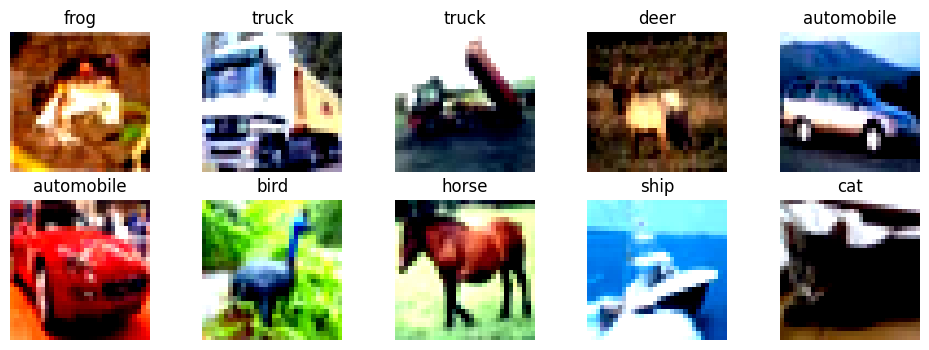

In [ ]:
# Display the image from each class
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
def imshow(img):
    img = img / 2 + 0.5   # unnormalize (rough)
    img = img.numpy().transpose((1, 2, 0))
    plt.imshow(img)
    plt.axis("off")

# Display first 10 images
plt.figure(figsize=(12, 4))
for i in range(10):
    image, label = train_dataset[i]
    plt.subplot(2, 5, i+1)   # 2 rows, 5 columns
    imshow(image)
    plt.title(classes[label])
plt.show()

In [ ]:
# Define CNN model

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)  # output: 32x28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1) # output: 64x14x14
        self.pool = nn.MaxPool2d(2, 2)  # downsample by 2
        self.fc1 = nn.Linear(64*8*8, 128)   # flatten to fully connected
        self.fc2 = nn.Linear(128, 10)       # 10 output classes (digits 0–9)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        #x = self.pool(F.relu(self.conv1(x)))   # conv1 -> relu -> pool
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        #x = self.pool(F.relu(self.conv2(x)))   # conv2 -> relu -> pool
        x = x.view(-1, 64*8*8)                  # flatten
        x = self.fc1(x)
        x = F.relu(x)
        #x = F.relu(self.fc1(x))                # fully connected
        x = self.fc2(x)                        # output layer
        return x

In [ ]:
# Training phase

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()    # softmax + log loss
optimizer = optim.Adam(model.parameters(), lr=0.001)


def train(model, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} [{batch_idx*len(data)}/{len(train_loader.dataset)}]  Loss: {loss.item():.4f}")

In [ ]:
# Test the model
def test(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")
    return accuracy


In [ ]:
# Train and test the model
best_acc = 0.0
for epoch in range(1, 3):
    train(model, train_loader, optimizer, criterion, epoch)
    acc=test(model, test_loader, criterion)
    if acc > best_acc:
        best_acc = acc
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'accuracy': acc
        }
        torch.save(checkpoint, "cifar10_best_model.pth")
        print(f" Saved Best Model with Acc: {acc:.2f}%")

Epoch 1 [0/50000]  Loss: 2.3054
Epoch 1 [6400/50000]  Loss: 1.5832
Epoch 1 [12800/50000]  Loss: 1.5578
Epoch 1 [19200/50000]  Loss: 1.3078
Epoch 1 [25600/50000]  Loss: 1.1673
Epoch 1 [32000/50000]  Loss: 0.9664
Epoch 1 [38400/50000]  Loss: 0.9835
Epoch 1 [44800/50000]  Loss: 0.8997

Test set: Average loss: 0.0010, Accuracy: 6309/10000 (63.09%)

 Saved Best Model with Acc: 63.09%
Epoch 2 [0/50000]  Loss: 0.9442
Epoch 2 [6400/50000]  Loss: 1.0550
Epoch 2 [12800/50000]  Loss: 0.8749
Epoch 2 [19200/50000]  Loss: 0.7616
Epoch 2 [25600/50000]  Loss: 0.9314
Epoch 2 [32000/50000]  Loss: 0.9147
Epoch 2 [38400/50000]  Loss: 0.9054
Epoch 2 [44800/50000]  Loss: 0.9451

Test set: Average loss: 0.0009, Accuracy: 6874/10000 (68.74%)

 Saved Best Model with Acc: 68.74%


In [ ]:
#load CIFAR 100 dataset

train_dataset_c100 = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset_c100 = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_loader_c100 = DataLoader(train_dataset_c100, batch_size=128, shuffle=True)
test_loader_c100 = DataLoader(test_dataset_c100, batch_size=128, shuffle=False)


pretrained_cnn = CNN()
checkpoint = torch.load('cifar10_best_model.pth')
pretrained_cnn.load_state_dict(checkpoint['model_state_dict'])
pretrained_cnn.eval()

100%|██████████| 169M/169M [00:04<00:00, 38.9MB/s]


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
class Backbone(nn.Module):
    def __init__(self, pretrained_model):
        super(Backbone, self).__init__()
        self.conv1 = pretrained_model.conv1
        self.conv2 = pretrained_model.conv2
        self.pool = pretrained_model.pool

    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        return x

backbone = Backbone(pretrained_cnn)

In [ ]:
class TransferCNN(nn.Module):
    def __init__(self, backbone, num_classes):
        super(TransferCNN, self).__init__()
        self.feature_extractor = backbone   # <-- must match this name
        self.classifier = nn.Sequential(
            nn.Linear(64*16*16,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0),-1)
        x = self.classifier(x)
        return x

model_c100 = TransferCNN(backbone, num_classes=100).to(device)

for param in model_c100.feature_extractor.parameters():
    param.requires_grad = False

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_c100.parameters(), lr=0.001)

# ----------------------------
# 7. Training and testing loop
# ----------------------------
num_epochs = 10
for epoch in range(num_epochs):
    model_c100.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_c100(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Test
    model_c100.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_c100(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100*correct/total:.2f}%\n")

Epoch [1/10], Loss: 1.0880
Test Accuracy: 64.89%

Epoch [2/10], Loss: 0.7842
Test Accuracy: 67.37%

Epoch [3/10], Loss: 0.5986
Test Accuracy: 69.22%

Epoch [4/10], Loss: 0.4294
Test Accuracy: 69.71%

Epoch [5/10], Loss: 0.2921
Test Accuracy: 69.02%

Epoch [6/10], Loss: 0.1898
Test Accuracy: 69.79%

Epoch [7/10], Loss: 0.1377
Test Accuracy: 68.42%

Epoch [8/10], Loss: 0.1246
Test Accuracy: 68.72%

Epoch [9/10], Loss: 0.0990
Test Accuracy: 69.89%

Epoch [10/10], Loss: 0.0946
Test Accuracy: 69.19%



In [ ]:
import kagglehub

path = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uc-merced-land-use-dataset' dataset.
Path to dataset files: /kaggle/input/uc-merced-land-use-dataset


In [ ]:
import os

print(os.listdir(path))

['UCMerced_LandUse']


In [ ]:
data_dir = os.path.join(path, "UCMerced_LandUse", "Images")
print(os.listdir(data_dir)[:5])

['airplane', 'tenniscourt', 'river', 'denseresidential', 'parkinglot']


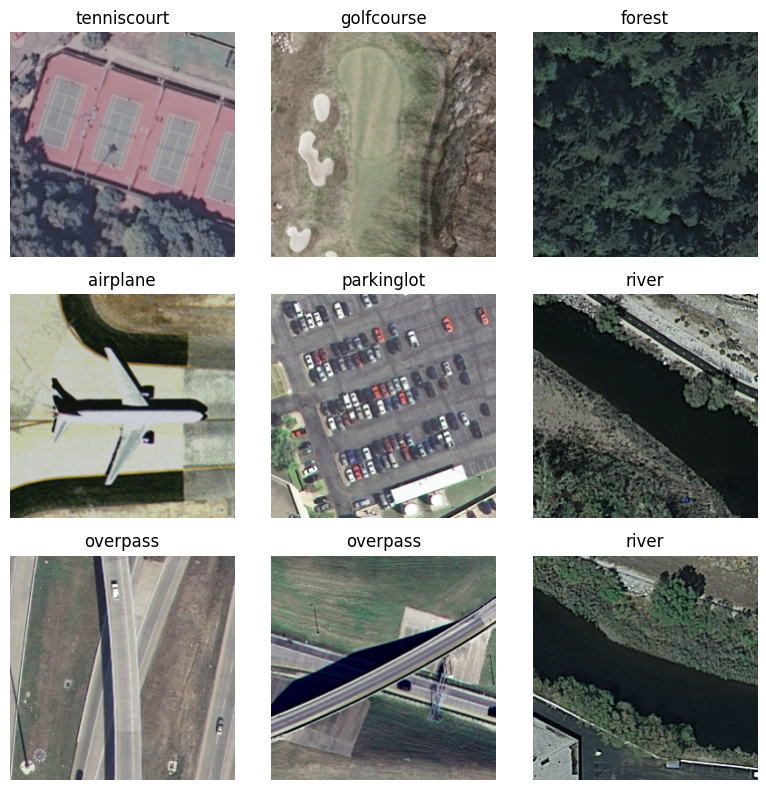

In [ ]:

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

vis_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

vis_dataset = datasets.ImageFolder(data_dir, transform=vis_transform)
vis_loader = DataLoader(vis_dataset, batch_size=9, shuffle=True)

images, labels = next(iter(vis_loader))
classes = vis_dataset.classes

plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i].permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

dataset = datasets.ImageFolder(data_dir, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_data, val_data = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

print("Classes:", dataset.classes)

Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet18(pretrained=True)

#  Freeze ALL layers first
for param in model.parameters():
    param.requires_grad = False

#  Unfreeze LAST block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 21)

In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 160.5368
Epoch 2, Loss: 144.0206
Epoch 3, Loss: 130.0740
Epoch 4, Loss: 118.6189
Epoch 5, Loss: 107.6232


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 64.29%
